<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->

# Mission Sequence and Finite-Burn Propagation Demo
---
*Scarabaeus OD Framework | Last revised 2026*

## What this notebook covers

This notebook is a self-contained walkthrough of **multi-arc trajectory propagation** using
the Scarabaeus `MissionSequence` API.  It shows:

| # | Topic |
|---|-------|
| 1 | Parsing a maneuver specification file with `ManeuverParser` |
| 2 | Defining a heliocentric spacecraft and initial state |
| 3 | Building force models and propagators for coast and finite-burn arcs |
| 4 | Assembling and propagating a `MissionSequence` |
| 5 | Visualizing the propagated trajectory |
| 6 | Visualizing mass evolution during finite burns |
| 7 | Impulsive burn pattern — `addLeg` + `addBurn` + `addLeg` |

## How to run

Run cells top-to-bottom from the **project root** directory (`scarabaeus/`).
The first code cell navigates there automatically if you opened the notebook from `tutorials/`.

## 0. Imports and Setup

We import Scarabaeus, the standard scientific stack, load SPICE kernels, and define
units and frames used throughout the notebook.

All data paths are relative to the **project root**.
The `locked_generic.tm` meta-kernel loads planetary ephemerides (DE440),
leap-seconds, and Earth ground-station SPKs.

In [1]:
import scarabaeus as scb
import supplementary as supp

from pathlib import Path

import numpy as np

# load tutorial data
data = supp.load_data()

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.mk.path)

# define units and frame
kg, km, sec, hr, N = scb.Units.get_units(['kg', 'km', 'sec', 'hr', 'N'])
frame = scb.Frame('J2000')

SCB supplementary data up to date.


## 2. Maneuver Specification File

Finite burns are loaded from an example measurement specification file which is
a comma-delimited (CSV) file produced by mission-design tools (e.g. GMAT).

### File format

The first row is a header that names every column.  Each subsequent row represents
**one burn segment** with the following key columns (0-indexed within the repeating block):

| Column index | Name | Description |
|:---:|:---:|---|
| 0 | `EVENTNAME` | Segment identifier |
| 1 | `NUMBER_OF_MANEUVERS` | Maneuvers per row (always `1` here) |
| 2 | `FRAME` | Reference frame (e.g. `EME2000`) |
| 3 | `EPOCH(ET)` | Burn **start** time (UTC string, converted to TDB via SPICE) |
| 4–6 | `THRX / THRY / THRZ` | Unit thrust-direction components (unitless) |
| 7 | `THRMAG [N]` | Thrust magnitude (Newtons) |
| 8 | `SMASS [kg]` | Spacecraft mass at burn start (kg) |
| 9 | `MDOT [kg/s]` | Propellant mass-flow rate |
| 13 | `DUR [s]` | Burn duration (seconds) — added to EPOCH to compute end time |
| 14 | `EPOCH(ET seconds)` | Burn start as raw TDB ET seconds |

`ManeuverParser._parse_maneuver_spec` reads this file and returns a list of
`Maneuver` objects, one per row.

In [2]:
spec_path = data.example_meas_spec.path

parser = scb.ManeuverParser()
with open(spec_path) as fh:
    burns = parser._parse_maneuver_spec(fh)

burn_start = lambda b: float(np.atleast_1d(b.start_time.times.values)[0])
burn_end   = lambda b: float(np.atleast_1d(b.end_time.times.values)[0])

print(f'Parsed {len(burns)} burn segments from:')
print(f'  {Path(spec_path).name}')
print()
print(f'{"Segment":<10} {"Start (UTC)":<30} {"Duration [hr]":>15}')
print('-' * 58)
for i, burn in enumerate(burns):
    start, end = burn.start_time, burn.end_time
    dur_hr = (end - start).values / 3600.0
    thr = float(np.atleast_1d(burn.thrust.values)[0])
    print(f"{i:<10} {start.to(rep = 'CAL')} {dur_hr:>15.1f} F = {thr}")

Parsed 15 burn segments from:
  example.mission_maneuver_spec

Segment    Start (UTC)                      Duration [hr]
----------------------------------------------------------
0          2030 SEP 16 02:43:16.948 (TDB)           124.8 F = 0.0001
1          2030 SEP 21 07:31:16.952 (TDB)           124.8 F = 0.00011428571
2          2030 SEP 26 12:19:16.957 (TDB)           124.8 F = 0.00012857143
3          2030 OCT 01 17:07:16.961 (TDB)           124.8 F = 0.00014285714
4          2030 OCT 06 21:55:16.966 (TDB)           124.8 F = 0.00015714285999999999
5          2030 OCT 12 02:43:16.970 (TDB)           124.8 F = 0.00017142857
6          2030 OCT 17 07:31:16.975 (TDB)           124.8 F = 0.00018571429
7          2030 OCT 22 12:19:16.979 (TDB)           124.8 F = 0.0002
8          2030 OCT 27 17:07:16.984 (TDB)           124.8 F = 0.00021428571
9          2030 NOV 01 21:55:16.988 (TDB)           124.8 F = 0.00022857143
10         2030 NOV 07 02:43:16.993 (TDB)           124.8 F = 0.0

## 3. Spacecraft and Initial State

We define a heliocentric spacecraft whose initial mass matches the `SMASS` value
of the first burn segment (`~2000 kg`).  The initial position and velocity are
approximate heliocentric values placed one day before the first burn.

The `StateDefinition.from_components` API constructs the state vector as a list of
tuples:

```python
('component_name', size, 'estimated'|'consider', 'dynamic'|'static', body, ArrayWFrame)
```

For **non-first** legs the position/velocity is NaN-initialised — the sequence
propagator overwrites these with the terminal state of the preceding arc.

In [3]:
# ── spacecraft ───────────────────────────────────────────────────
dry_mass  = scb.ArrayWUnits(1500.0, kg)
fuel_mass = scb.ArrayWUnits(500.0,  kg)
area      = scb.ArrayWUnits(1e-6,   km**2)
cr        = scb.ArrayWUnits(1.5,    None)

Orbiter = scb.Spacecraft('Orbiter', -60000, dry_mass + fuel_mass, area, cr)

# ── origin ────────────────────────────────────────────────────────
origin = scb.CelestialBody.from_constants('SUN')

# ── timing — start one day before the first burn ──────────────────
t_burn0_start = scb.EpochArray(burn_start(burns[0]), sys = 'TDB')
t_burn0_end   = scb.EpochArray(burn_end(burns[0]), sys = 'TDB')
t_coast0_start = t_burn0_start - scb.ArrayWUnits(86400.0, sec)   # 1 day before burn 0

print(f"Coast start : {t_coast0_start.to(rep = 'CAL')}")
print(f"Burn 0 start: {t_burn0_start.to(rep = 'CAL')}")
print(f"Burn 0 end  : {t_burn0_end.to(rep = 'CAL')}")
print(f"Burn 0 dur  : {(t_burn0_end - t_burn0_start).values/86400} days")

# ── initial 6-DOF state (approximate heliocentric values) ─────────
r0 = np.array([-1.5e8,  9.0e7,  3.0e7])   # [km]  ~1 AU from Sun
v0 = np.array([ -8.0,  -18.0,  -5.0])     # [km/s] approximate heliocentric speed

pos_0 = scb.ArrayWFrame(scb.ArrayWUnits(r0, km),        frame)
vel_0 = scb.ArrayWFrame(scb.ArrayWUnits(v0, km / sec),  frame)

initial_state_def = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter, pos_0),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter, vel_0),
])
initial_state = scb.StateArray(
    epoch=t_coast0_start,
    origin=origin,
    state=initial_state_def,
)
print(f'\nInitial mass: {float((dry_mass + fuel_mass).values):.1f} kg')

Coast start : 2030 SEP 15 02:43:16.948 (TDB)
Burn 0 start: 2030 SEP 16 02:43:16.948 (TDB)
Burn 0 end  : 2030 SEP 21 07:31:16.952 (TDB)
Burn 0 dur  : 5.2000000520836975 days



Initial mass: 2000.0 kg


## 4. Build Force Models and Propagators

Each arc gets its own `ForceModelTranslation` and `Propagator`.

| Arc | `finite_burn` | `maneuver` |
|---|---|---|
| Coast (before burn) | `False` | — |
| Finite burn arc | `True` | `burns[0]` |
| Final coast (after burn) | `False` | — |

The integration step is `dt = 3600 s` (1 hour).

**Non-first arcs** are initialised with `StateDefinition.empty_pv`:

```python
sv = StateArray(
    epoch=EpochArray(np.zeros(1), sys='TDB'),
    origin=origin,
    state=StateDefinition.empty_pv(Orbiter, frame=J2000),
)
```

`empty_pv` allocates a NaN position/velocity in `km` / `km/s` and marks
them `estimated` + `dynamic`.  The epoch zero is a placeholder — the
sequence propagator replaces both the NaN state and the epoch with the
terminal state of the preceding arc before integration begins.

In [4]:
dt = scb.ArrayWUnits(1, hr)
dt_sec = 3600.0 

def empty_state(spacecraft, origin, frame):
    """StateArray for non-first legs using StateDefinition.empty_pv.

    StateDefinition.empty_pv fills position and velocity with NaN
    (units km / km/s by default) and marks them as 'estimated' / 'dynamic'.
    The epoch is set to zero — the sequence propagator will overwrite both
    the NaN values and the epoch at run-time from the preceding arc's
    terminal state.
    """
    return scb.StateArray(
        epoch=scb.EpochArray(np.zeros(1), sys='TDB'),
        origin=origin,
        state=scb.StateDefinition.empty_pv(spacecraft, frame=frame),
    )

# ── Coast before burn 0 (1 day) ──────────────────────────────────
ep_coast0   = scb.EpochArray.interval(t_coast0_start.to(rep = 'NUM'),
                                      t_burn0_start.to(rep = 'NUM')+dt, dt, sys = 'TDB')
fm_coast0   = scb.ForceModelTranslation(primary_body=Orbiter, cannonball_SRP=True)
prop_coast0 = scb.Propagator(
    primary_body=Orbiter, state_vector=initial_state,
    tspan=ep_coast0, force_models=fm_coast0,
)

# ── Finite burn arc 0 ────────────────────────────────────────────
ep_burn0  = scb.EpochArray.interval(t_burn0_start.to(rep = 'NUM'), 
                                    t_burn0_end.to(rep = 'NUM'), 
                                    dt, sys = 'TDB')
sv_burn0  = empty_state(Orbiter, origin, frame)
fm_burn0  = scb.ForceModelTranslation(
    primary_body=Orbiter, cannonball_SRP=True,
    finite_burn=True, maneuver=burns[0],
)
prop_burn0 = scb.Propagator(
    primary_body=Orbiter, state_vector=sv_burn0,
    tspan=ep_burn0, force_models=fm_burn0,
)

# ── Final coast (6 hours after burn 0) ───────────────────────────
coast_final_start_num = ep_burn0.times.values[-1]
coast_final_end_num   = coast_final_start_num + 6 * 3600  # 6 hours in seconds
ep_coast_final      = scb.EpochArray.interval(coast_final_start_num, 
                                              coast_final_end_num + dt_sec, dt, sys = 'TDB')
sv_coast_final      = empty_state(Orbiter, origin, frame)
fm_coast_final      = scb.ForceModelTranslation(primary_body=Orbiter, cannonball_SRP=True)
prop_coast_final    = scb.Propagator(
    primary_body=Orbiter, state_vector=sv_coast_final,
    tspan=ep_coast_final, force_models=fm_coast_final,
)

print('Propagators built:')
for label, ep in [('Coast before', ep_coast0), ('Burn 0', ep_burn0), ('Final coast', ep_coast_final)]:
    n = len(ep.times.values)
    t0, tf = ep.to(rep = 'CAL').times[0], ep.to(rep = 'CAL').times[-1]
    print(f'  {label:<16} {n:>4} steps   '
          f"{t0}  →  {tf}")

print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
print('Coast 0 last: ', ep_coast0.times.values[-1])
print('Burn 0 first:', ep_burn0.times.values[0])
print('Burn 0 last: ', ep_burn0.times.values[-1])
print('Coast f first:', ep_coast_final.times.values[0])

Propagators built:
  Coast before       25 steps   2030 SEP 15 02:43:16.948  →  2030 SEP 16 02:43:16.948
  Burn 0            125 steps   2030 SEP 16 02:43:16.948  →  2030 SEP 21 06:43:16.948
  Final coast         7 steps   2030 SEP 21 06:43:16.948  →  2030 SEP 21 12:43:16.948
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Coast 0 last:  969029066.1305069
Burn 0 first: 969029066.1305069
Burn 0 last:  969475466.1305069
Coast f first: 969475466.1305069


## 5. Assemble and Propagate the Mission Sequence

`MissionSequence` chains the arcs in order.  The propagation engine:

1. Propagates the **coast leg** from the given initial state.
2. Inserts an automatic **node** at the burn start (no state discontinuity).
3. Propagates **burn 0** forward, applying thrust and mass depletion at each step.
4. Inserts another node at the burn end.
5. Propagates the **final coast** from the post-burn state.

Use `addLeg` for coast arcs and `addFiniteBurn` for thrust arcs.

In [5]:
MS = scb.MissionSequence('FiniteBurnDemo')
MS.addLeg(
    'Coast before burn 0',
    state_vector=initial_state,
    prop=prop_coast0,
    dt=dt,
)
MS.addFiniteBurn(
    'Burn 0',
    state_vector=sv_burn0,
    prop=prop_burn0,
    dt=dt,
)
MS.addLeg(
    'Final coast',
    state_vector=sv_coast_final,
    prop=prop_coast_final,
    dt=dt,
)

print('Sequence types :', MS.types)
print('Segment names  :', [n for n in MS.names if 'Node' not in n])

scenario = MS.propagate()
print('Done.')

t_all  = scenario.total_epochsTDB.times.values
hours  = (t_all - t_all[0]) / 3600.0
print(f'Total propagated steps : {len(t_all)}')
print(f'Total duration         : {hours[-1]:.1f} hr')

Sequence types : ['Leg', 'Node', 'Finite Burn', 'Node', 'Leg']
Segment names  : ['Coast before burn 0', 'Burn 0', 'Final coast']

--- Propagating Segment 1/5: 'Coast before burn 0' [Leg] ---

[IC] segment='Coast before burn 0' type='Leg' epoch=968942666.1305069 sec (TDB)
  position     n= 3 sid=-60000 frame=J2000 vals[:6]=[-1.5e+08  9.0e+07  3.0e+07]
  velocity     n= 3 sid=-60000 frame=J2000 vals[:6]=[ -8. -18.  -5.]

                            Starting propagation...                             


Integrating:   0%|                                                       | 0.00/86400.00 s [00:00<?]

Integrating:   0%|                                                       | 0.00/86400.00 s [00:00<?]

Integrating:   0%|                                                 | 0.01/86400.00 s [00:00<5:32:25]

Integrating:   0%|                                                       | 0.00/86400.00 s [00:00<?]

...

Integrating: 100%|███████████████████████████████████████████████| 21600.00/21600.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████████| 21600.00/21600.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████████| 21600.00/21600.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.

[GLOBAL STATE after 'Final coast']
  key=('position', 3, -60000, 'J2000', 0) -> global[0:3] = [-1.53879518e+08  7.96968013e+07  2.71220628e+07]
  key=('velocity', 3, -60000, 'J2000', 0) -> global[3:6] = [ -5.97600807 -19.15473055  -5.37741934]


Done.
Total propagated steps : 155
Total duration         : 154.0 hr


## 6. Trajectory Visualization

Position and velocity histories are accessed from the `ScenarioSetup` object returned
by `MS.propagate()`:

```python
r = scenario.total_position.quantity.values   # shape (3, N)  [km]
v = scenario.total_velocity.quantity.values   # shape (3, N)  [km/s]
```

The grey bands mark the finite-burn arc.

In [6]:
r = np.array(scenario.total_position.quantity.values, dtype=float)  # (N, 3)
v = np.array(scenario.total_velocity.quantity.values, dtype=float)  # (N, 3)

# burn window in hours-from-start
h_burn_start = (t_burn0_start.to(rep = 'NUM').times  - t_all[0]) / 3600.0
h_burn_end   = (t_burn0_end.to(rep = 'NUM').times    - t_all[0]) / 3600.0



## 7. Mass Evolution During Finite Burns

During a finite-burn arc the Scarabaeus propagator integrates the mass ODE

$$\dot{m}(t) = -\dot{m}_{burn}$$

and stores the result as an `SCBPolynomial` inside the spacecraft.
After propagation, `Spacecraft.mass(t)` evaluates this polynomial at any epoch
within the valid domain of each arc.

We call it at every epoch in `scenario.total_epochsTDB` to reconstruct the
full mass history across coast and burn arcs.

In [7]:
# Evaluate mass at every propagated epoch
# Orbiter._mass_profile is updated by the propagator for each arc;
# mass(t) dispatches to the correct arc polynomial via get_mass().
mass_vals = np.array(
    [float(np.asarray(Orbiter.mass(float(t)).values).ravel()[0]) for t in t_all]
)

m0     = mass_vals[0]
m_end  = mass_vals[-1]
mdot   = burns[0].mass_flow.values[0]
delta_m = m0 - m_end

print(f'Initial mass    : {m0:.3f} kg')
print(f'Final mass      : {m_end:.3f} kg')
print(f'Propellant used : {delta_m:.3f} kg')
print(f'Mass-flow rate  : {mdot:.4e} kg/s')

# Plot only during burn, scatter style
burn_mask = (hours >= h_burn_start) & (hours <= h_burn_end)

h_plot = hours[burn_mask][:-1]
m_plot = mass_vals[burn_mask][:-1]


Initial mass    : 2000.000 kg
Final mass      : 2000.000 kg
Propellant used : -0.000 kg
Mass-flow rate  : 5.9963e-06 kg/s


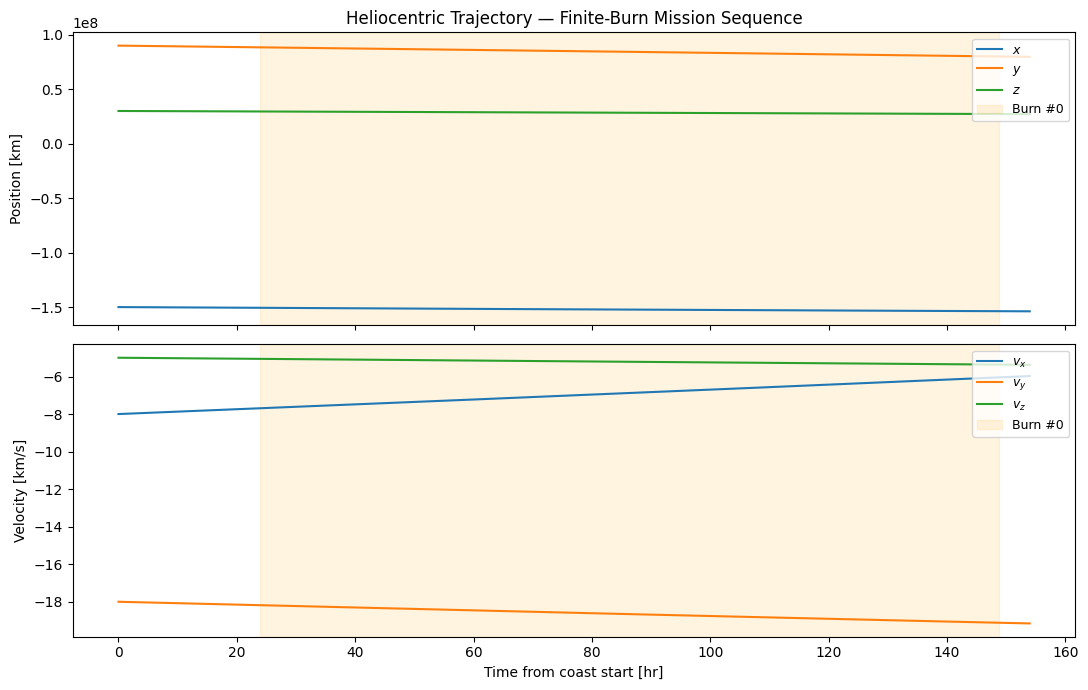

In [8]:
supp.supp_plotting.plot_fb_traj(r, v, hours, h_burn_start, h_burn_end)

## 9. Notes and Common Pitfalls

**Epoch continuity**: the `MissionSequence` validator checks that the last epoch of
each arc matches the first epoch of the next.  `make_epochs` ensures `t_arr[-1] == tf`
so there is no floating-point gap at arc boundaries.

**NaN-initialized states**: non-first legs must be constructed with NaN
position/velocity and a NaN epoch.  The sequence propagator fills these at
runtime from the terminal state of the preceding arc.  Providing real values
for subsequent arcs is silently ignored.

**`addFiniteBurn` vs `addLeg`**: use `addFiniteBurn` for any arc whose
`ForceModelTranslation` was built with `finite_burn=True`.  Mixing them
(e.g., `addLeg` with a thrust force model) will propagate without thrust.

**Nodes are inserted automatically**: `addFiniteBurn` inserts a node before
the burn, and `addLeg` following a burn inserts one before the coast.
Avoid calling `addNode` manually unless you need a named boundary marker.

**Mass units**: `ManeuverParser` stores `mass_flow` in `kg/sec` and `thrust` in `N`.
The Scarabaeus propagator stores thrust internally in `kN` so that dividing by
mass in kg yields acceleration directly in `km/s²`.